In [1]:
!pip install --upgrade pip
!pip install hazm==0.7.0
!pip install datasets scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 65.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'nltk' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'nltk'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for nltk: filename=nltk-3.3-py3-none-any.whl size=1394471 sha256=cbc552c2f49afe65fb21313efd6c3724953f880a50da5938117114f2b0f40376
  Stored in directory

In [2]:
# Fix inspect.formatargspec for hazm on Python 3.11+
import inspect

if not hasattr(inspect, 'formatargspec'):
    def formatargspec(*args, **kwargs):
        from inspect import signature, _empty
        sig = signature(lambda: None)
        return str(sig)
    inspect.formatargspec = formatargspec

# Patch NumPy deprecated aliases
import numpy as np

for name, value in {
    'bool': bool,
    'int': int,
    'float': float,
    'complex': complex,
    'object': object,
    'str': str,
    'long': int,
    'dtypes': np.dtype,
}.items():
    if not hasattr(np, name):
        setattr(np, name, value)

# Install required packages
!pip install hazm==0.7.0 datasets scikit-learn matplotlib

<ipython-input-2-5d8b0d36863b>:24: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, name):
<ipython-input-2-5d8b0d36863b>:24: FutureWarning: In the future `np.str` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, name):


In [3]:
import numpy as np

# Patch deprecated NumPy aliases
deprecated_aliases = {
    'bool': bool,
    'int': int,
    'float': float,
    'complex': complex,
    'object': object,
    'str': str,
    'long': int,
    'dtypes': np.dtype
}

for alias, actual in deprecated_aliases.items():
    if not hasattr(np, alias):
        setattr(np, alias, actual)

In [4]:
import hazm
import pandas as pd
import tensorflow as tf

In [6]:
food = pd.read_csv("/content/Snappfood - Sentiment Analysis.csv",encoding='utf-8', sep='\t+', on_bad_lines='skip')
food

<ipython-input-6-aa7b954c8887>:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  food = pd.read_csv("/content/Snappfood - Sentiment Analysis.csv",encoding='utf-8', sep='\t+', on_bad_lines='skip')


,comment,label,label_id
0,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,SAD,1
1,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از مو...,HAPPY,0
2,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط...,SAD,1
3,عالللی بود همه چه درست و به اندازه و کیفیت خوب...,HAPPY,0
4,شیرینی وانیلی فقط یک مدل بود.,HAPPY,0
...,...,...,...
69995,سلام من به فاکتور غذاهایی که سفارش میدم احتیاج...,SAD,1
69996,سایز پیتزا نسبت به سفارشاتی که قبلا گذشتم کم ش...,SAD,1
69997,من قارچ اضافه رو اضافه کرده بودم بودم اما اگر ...,HAPPY,0
69998,همرو بعد ۲ساعت تاخیر اشتباه آوردن پولشم رفت رو...,SAD,1


In [7]:
food.head()

,comment,label,label_id
0,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,SAD,1
1,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از مو...,HAPPY,0
2,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط...,SAD,1
3,عالللی بود همه چه درست و به اندازه و کیفیت خوب...,HAPPY,0
4,شیرینی وانیلی فقط یک مدل بود.,HAPPY,0


In [8]:
food.shape

(70000, 3)

In [9]:
print(food.isnull().sum())
print(food.duplicated().sum())
print(food.info())
print(food.describe())
print(food.nunique())

comment     0
label       0
label_id    0
dtype: int64
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   comment   70000 non-null  object
 1   label     70000 non-null  object
 2   label_id  70000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ MB
None
           label_id
count  70000.000000
mean       0.500000
std        0.500004
min        0.000000
25%        0.000000
50%        0.500000
75%        1.000000
max        1.000000
comment     70000
label           2
label_id        2
dtype: int64


<Axes: xlabel='label', ylabel='count'>

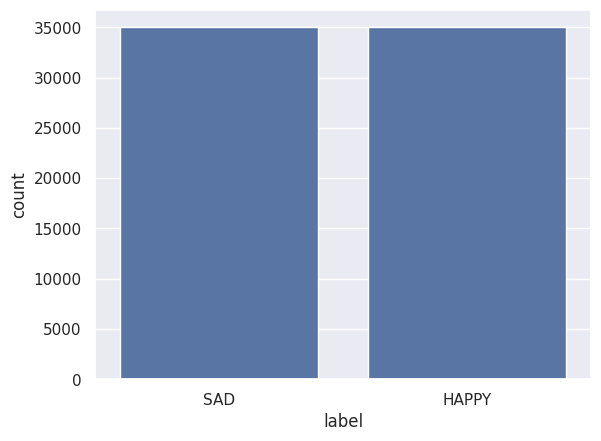

In [10]:
import seaborn as sns

sns.set(style="darkgrid")
sns.countplot(x = "label" , data = food)

In [18]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

from hazm import Normalizer, Stemmer, word_tokenize, Lemmatizer, stopwords_list
# from gensim.models import Word2Vec, FastText
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from wordcloud import WordCloud

# *Preprocessing*

In [19]:
# del food["label"]
# token
# del stop words
# stemming

We check if there is a happy label with label_id = 1.0 because thats an exception and the equivalent id for happy is 0.0 and for sad is 1.0

In [20]:
food.query('label == "HAPPY" and label_id == 1.0')

,comment,label,label_id


In [21]:
food.query('label == "SAD" and label_id == 0')

,comment,label,label_id


In [22]:
X = (food['comment'])
y = (food['label_id'])

X.shape, y.shape

((70000,), (70000,))

Remove all punctuation(in both English and Persian), and I also deleted english alphabet in order to have persian text and nothing else.

In [23]:
X = X.apply(lambda x: re.sub(r'[\da-zA-Z\!\(\)\-\[\]\{\}\;\:\'\"\\\,\<\>\.\/\?\@\#\$\%\^\&\*\_\~\؟\،\٪\×\÷\»\«]', '', x))

X.head()

,comment
0,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح
1,قرار بود ساعته برسه ولی نیم ساعت زودتر از موق...
2,قیمت این مدل اصلا با کیفیتش سازگاری نداره فقط ...
3,عالللی بود همه چه درست و به اندازه و کیفیت خوب...
4,شیرینی وانیلی فقط یک مدل بود


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

Use hazm library to make the data more understandable for the model. First we normalize X (both train and test)

In [25]:
normalizer = Normalizer()
X_train = X_train.apply(lambda x: normalizer.normalize(x))
X_test = X_test.apply(lambda x: normalizer.normalize(x))

X_train.head(10)

,comment
52484,غذا خیلیییی دیر بدستم رسید نزدیک دو ساعت فکرکنم
53947,مرغ کاملا مونده بود و معلوم بود از زمان سوخاری...
45608,نسبت به قبل کیفیت غذاتون افت کرده راستش اصلا ن...
15573,عاااااالی سریع و بدون نقص
61617,شیرینی‌ها تازه و خوشمزه بود برخورد پیک خیلی خو...
21923,خیلی سریع و درست
44744,در شرینی‌تر از هر مدل شیرینی عدد گذاشتند واقعا...
57622,ساندویچ‌های پلاک کوچکتر و کوچکتر می‌شود
2139,من ازش این رستوران زیاد سفارش میدم فیله مثل هم...
1444,سالاد فرانسوی که سفارش داده بودیم با عکس مغایر...


In [26]:
# Use hazm's word tokenizer. As a resualt each word in a sentence was splitted and now in each row we have a list of words

X_train = X_train.apply(lambda x: word_tokenize(x))
X_test = X_test.apply(lambda x: word_tokenize(x))

X_test.head()

,comment
22941,"[همبرگر, ذغالی, گرفتم, اصلأ, خوب, نه_بود, بیشت..."
43544,"[شرینی, خوب, و, تازه, بود, ممنون]"
36799,"[واقعا, اگه, از, یک, غذا, بدم, اومده, باشه, از..."
33909,"[با, اینکه, اعلام, شده_بود, سالم, برسانند, متا..."
69510,"[سیب, زمینیش, فوق, العاده, خوشمزه, بود]"


In [27]:
# Hazm stemmer is now used to be applied on the words

stemmer = Stemmer()
X_train = X_train.apply(lambda words: [stemmer.stem(word) for word in words])
X_test = X_test.apply(lambda words: [stemmer.stem(word) for word in words])

X_test.head()

,comment
22941,"[همبرگر, ذغال, گرف, اصلأ, خوب, نه_بود, ب, به, ..."
43544,"[شرین, خوب, و, تازه, بود, ممنون]"
36799,"[واقعا, اگه, از, یک, غذا, بد, اومده, باشه, از,..."
33909,"[با, اینکه, اعلا, شده_بود, سال, برسانند, متاسف..."
69510,"[سیب, زمین, فوق, العاده, خوشمزه, بود]"


In [28]:
# The roots of some word are found by utilizing hazm's lemmatizer

lemmatizer = Lemmatizer()
X_train = X_train.apply(lambda words: [lemmatizer.lemmatize(word) for word in words])
X_test = X_test.apply(lambda words: [lemmatizer.lemmatize(word) for word in words])

X_train.head()

,comment
52484,"[غذا, خیلی, دیر, بدس, رسید, نزدیک, دو, ساع, فک..."
53947,"[مرغ, کاملا, مونده, بود#باش, و, معلو, بود#باش,..."
45608,"[نسب, به, قبل, کیف, غذاتون, اف, کرده, راست, اص..."
15573,"[عاااااال, سریع, و, بدون, نقص]"
61617,"[شیرینی, تازه, و, خوشمزه, بود#باش, برخورد, پیک..."


In [29]:
# At the last step of preprocessing the list of words in each row are now joined to become something like a sentence

X_train = X_train.apply(lambda x: ' '.join(x)).to_list()
X_test = X_test.apply(lambda x: ' '.join(x)).to_list()

In [30]:
X_train

['غذا خیلی دیر بدس رسید نزدیک دو ساع فکرکن',
 'مرغ کاملا مونده بود#باش و معلو بود#باش از ز سوخار شدن خیل گذشته',
 'نسب به قبل کیف غذاتون اف کرده راست اصلا نتونس خورد#خور ریخ بیرون نمیدون چرا مرغ یه بو میداد',
 'عاااااال سریع و بدون نقص',
 'شیرینی تازه و خوشمزه بود#باش برخورد پیک خیل خوب و مودبانه بود#باش ممنون',
 'خیل سریع و درس',
 'در شرینی از هر مدل شیرین عدد گذاشت#گذار واقعا افتضاح بود#باش',
 'ساندویچ پلاک کوچک و کوچک شد#شو',
 'من از این رستور زیاد سفار مید فیله مثل همیشه خوب بود#باش اما سبب زمین بد بود#باش تعداد سیب زمین سوخته زیاد بود#باش مثل همیشه ترد بود#باش',
 'سالاد فرانسو که سفار داد#ده با عکس مغایر دا در عکس خیار گوجه و انواع سبز موجود بود#باش اما در محصول ارسال درصد کاهو بود#باش با مقدار خیل ک سبز و خیار و گوجه ه ندا در اصل فقط کاهو بود#باش',
 'همه چیز عال بود#باش ؛ تن ایراد که میشه گرف این بود#باش که ظرف سالاد شیراز باز شد#شو و ریخت#ریز داخل نایلون',
 'تاخیر در تحویل بستن آب شده به دس رسید',
 'غذا عال بود#باش ول ب ار ساع طول کشید#کش تا بیاره واقعا اد از غذا سیر میشه',
 'کی

## *vectorizers*

In [31]:
vectorizer = TfidfVectorizer()
x_train = vectorizer.fit_transform(X_train)
x_test = vectorizer.transform(X_test)

# *Models ML*

In [32]:
rfc = RandomForestClassifier()
rfc.fit(x_train, y_train)
y_pred = rfc.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      3462
           1       0.81      0.89      0.85      3538

    accuracy                           0.84      7000
   macro avg       0.84      0.84      0.84      7000
weighted avg       0.84      0.84      0.84      7000



In [33]:
xgb = XGBClassifier()
xgb.fit(x_train, y_train)
Y_pred = xgb.predict(x_test)
print(classification_report(y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83      3462
           1       0.81      0.90      0.85      3538

    accuracy                           0.84      7000
   macro avg       0.85      0.84      0.84      7000
weighted avg       0.85      0.84      0.84      7000



In [41]:
clf_pipeline = Pipeline([
    ('tfidf', vectorizer),
    ('xgb', xgb)
])

Y_pred = clf_pipeline.predict(X_test)

print(classification_report(y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83      3462
           1       0.81      0.90      0.85      3538

    accuracy                           0.84      7000
   macro avg       0.85      0.84      0.84      7000
weighted avg       0.85      0.84      0.84      7000



In [35]:
clf_pipeline.predict(['حیف پولییی که به این غذا دادم!!!'])

array([1])

In [36]:
mnb = MultinomialNB()
mnb.fit(x_train, y_train)
y_pred = mnb.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.75      0.81      3462
           1       0.78      0.90      0.84      3538

    accuracy                           0.82      7000
   macro avg       0.83      0.82      0.82      7000
weighted avg       0.83      0.82      0.82      7000



In [37]:
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.80      0.84      3462
           1       0.82      0.89      0.85      3538

    accuracy                           0.85      7000
   macro avg       0.85      0.85      0.85      7000
weighted avg       0.85      0.85      0.85      7000



# *Save the Trained Model*

In [38]:
import pickle

with open('xgb.pkl', 'wb') as file:
    pickle.dump(xgb, file)

with open('vectorizer.pkl', 'wb') as file:
    pickle.dump(vectorizer, file)

# *DL Model*

# *ParsBERT *

In [39]:
! pip install transformers tensorflow numpy hazm

In [40]:
from transformers import BertTokenizer, TFBertForSequenceClassification
from tensorflow.keras.optimizers import Adam

# Load ParsBERT tokenizer and model
model_name = "HooshvareLab/bert-fa-base-uncased"  # ParsBERT
tokenizer = BertTokenizer.from_pretrained(model_name)
model = TFBertForSequenceClassification.from_pretrained(model_name, num_labels=2)  # Binary classification

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at HooshvareLab/bert-fa-base-uncased and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at HooshvareLab/bert-fa-base-uncased and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 219/219 [00:58<00:00,  3.75it/s]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.16      0.26      3462
           1       0.52      0.90      0.66      3538

    accuracy                           0.54      7000
   macro avg       0.57      0.53      0.46      7000
weighted avg       0.57      0.54      0.46      7000

Accuracy: 0.5367


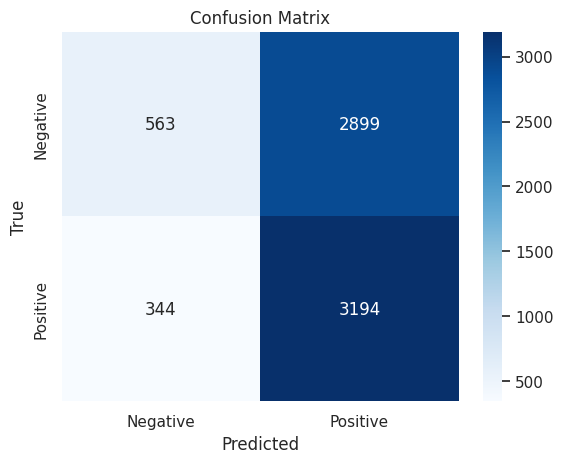

In [44]:
from transformers import BertTokenizer, TFBertForSequenceClassification
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

# Load tokenizer and model
model_name = "HooshvareLab/bert-fa-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = TFBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Parameters
batch_size = 32

# Predict in batches
predictions = []
for i in tqdm(range(0, len(X_test), batch_size)):
    batch_texts = X_test[i:i+batch_size]
    encodings = tokenizer(
        batch_texts,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="tf"
    )
    outputs = model(encodings)
    batch_preds = tf.argmax(outputs.logits, axis=1).numpy()
    predictions.extend(batch_preds)

# Convert predictions to numpy array
predictions = np.array(predictions)

# Evaluation
print("Classification Report:")
print(classification_report(y_test, predictions))

acc = accuracy_score(y_test, predictions)
print(f"Accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()